# Example: Image segmentation with UNETR model

This example demonstrates how to implement and train a model on image segmentation task. Below, we will be using the [Oxford Pets dataset](https://www.robots.ox.ac.uk/%7Evgg/data/pets/) containing images and masks of cats and dogs. We will implement from scratch the [UNETR](https://arxiv.org/abs/2103.10504) model using Flax NNX. We will train the model on a training set and compute image segmentation metrics on the training and validation sets. We will use [Orbax checkpoint manager](https://orbax.readthedocs.io/en/latest/api_reference/checkpoint.checkpoint_manager.html) to store best models during the training.

## Prepare image segmentation dataset and dataloaders

In this section we use the [Oxford Pets dataset](https://www.robots.ox.ac.uk/%7Evgg/data/pets/).
We download images and masks and provide a code to work with the dataset.
This approach can be easily extended to any image segmentation datasets and users can reuse this code for their own datasets.

In the code below we make a choice of using OpenCV and Pillow to read images and masks as NumPy arrays, [Albumentations](https://github.com/albumentations-team/albumentations) for data augmentations and
[`grain`](https://github.com/google/grain/) for batched data loading. Alternatively, one can use  [tensorflow_dataset](https://www.tensorflow.org/datasets) or [torchvision](https://pytorch.org/vision/stable/index.html) for the same task.

### Requirements installation

We will need to install the following Python packages:
```
!pip install -U opencv-python-headless grain albumentations Pillow
!pip install -U flax optax orbax-checkpoint
```

In [1]:
import jax
import flax
import optax
import orbax.checkpoint as ocp
print("Jax version:", jax.__version__)
print("Flax version:", flax.__version__)
print("Optax version:", optax.__version__)
print("Orbax version:", ocp.__version__)

Jax version: 0.10.1.dev20260519
Flax version: 0.12.7
Optax version: 0.2.8
Orbax version: 0.11.33


### Data download

Let's download the data and extract images and masks.

In [2]:
# !rm -rf /tmp/data/oxford_pets
# !mkdir -p /tmp/data/oxford_pets
# !wget https://thor.robots.ox.ac.uk/datasets/pets/images.tar.gz -O /tmp/data/oxford_pets/images.tar.gz
# !wget https://thor.robots.ox.ac.uk/datasets/pets/annotations.tar.gz -O /tmp/data/oxford_pets/annotations.tar.gz

# !cd /tmp/data/oxford_pets && tar -xf images.tar.gz
# !cd /tmp/data/oxford_pets && tar -xf annotations.tar.gz
# !ls /tmp/data/oxford_pets

We can also inspect the downloaded images folder, listing a subset of these files:

In [3]:
!ls /tmp/data/oxford_pets/images | wc -l
!ls /tmp/data/oxford_pets/images | head
!ls /tmp/data/oxford_pets/annotations/trimaps | wc -l
!ls /tmp/data/oxford_pets/annotations/trimaps | head

7393
Abyssinian_1.jpg
Abyssinian_10.jpg
Abyssinian_100.jpg
Abyssinian_100.mat
Abyssinian_101.jpg
Abyssinian_101.mat
Abyssinian_102.jpg
Abyssinian_102.mat
Abyssinian_103.jpg
Abyssinian_104.jpg
ls: write error: Broken pipe
7390
Abyssinian_1.png
Abyssinian_10.png
Abyssinian_100.png
Abyssinian_101.png
Abyssinian_102.png
Abyssinian_103.png
Abyssinian_104.png
Abyssinian_105.png
Abyssinian_106.png
Abyssinian_107.png
ls: write error: Broken pipe


### Train/Eval datasets

Let's implement the dataset class providing the access to the images and masks. The class implements `__len__` and `__getitem__` methods.
In this example, we do not have a hard training and validation data split, so we will use the total dataset and make a random training/validation split by indices.
For this purpose we provide a helper class to map indices into training and validation parts.

In [4]:
from typing import Any
from pathlib import Path

import cv2
import numpy as np
from PIL import Image  # we'll read images with opencv and use Pillow as a fallback


class OxfordPetsDataset:
    def __init__(self, path: Path):
        assert path.exists(), path
        self.path: Path = path
        self.images = sorted((self.path / "images").glob("*.jpg"))
        self.masks = [
            self.path / "annotations" / "trimaps" / path.with_suffix(".png").name
            for path in self.images
        ]
        assert len(self.images) == len(self.masks), (len(self.images), len(self.masks))

    def __len__(self) -> int:
        return len(self.images)

    def read_image_opencv(self, path: Path):
        img = cv2.imread(str(path))
        if img is not None:
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            None

    def read_image_pillow(self, path: Path):
        img = Image.open(str(path))
        img = img.convert("RGB")
        return np.asarray(img)

    def read_mask(self, path: Path):
        mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        # mask has values: 1, 2, 3
        # 1 - object mask
        # 2 - background
        # 3 - boundary
        # Define mask as 0-based int values
        mask = mask - 1
        return mask.astype("uint8")

    def __getitem__(self, index: int) -> dict[str, np.ndarray]:
        img_path, mask_path = self.images[index], self.masks[index]
        img = self.read_image_opencv(img_path)
        if img is None:
            # Fallback to Pillow if OpenCV fails to read an image
            img = self.read_image_pillow(img_path)
        mask = self.read_mask(mask_path)
        return {
            "image": img,
            "mask": mask,
        }


class SubsetDataset:
    def __init__(self, dataset, indices: list[int]):
        # Check input indices values:
        for i in indices:
            assert 0 <= i < len(dataset)
        self.dataset = dataset
        self.indices = indices

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, index: int) -> Any:
        i = self.indices[index]
        return self.dataset[i]

Now, let's define the total dataset and compute data indices for training and validation splits:

In [5]:
seed = 12
train_split = 0.7
dataset_path = Path("/tmp/data/oxford_pets")

dataset = OxfordPetsDataset(dataset_path)

rng = np.random.default_rng(seed=seed)
le = len(dataset)
data_indices = list(range(le))

# Let's remove few indices corresponding to corrupted images
# to avoid libjpeg warnings during the data loading
corrupted_data_indices = [3017, 3425]
for index in corrupted_data_indices:
    data_indices.remove(index)

random_indices = rng.permutation(data_indices)

train_val_split_index = int(train_split * le)
train_indices = random_indices[:train_val_split_index]
val_indices = random_indices[train_val_split_index:]

# Ensure there is no overlapping
assert len(set(train_indices) & set(val_indices)) == 0

train_dataset = SubsetDataset(dataset, indices=train_indices)
val_dataset = SubsetDataset(dataset, indices=val_indices)

print("Training dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Training dataset size: 5173
Validation dataset size: 2215


To verify our work so far, let's display few training and validation images and masks:

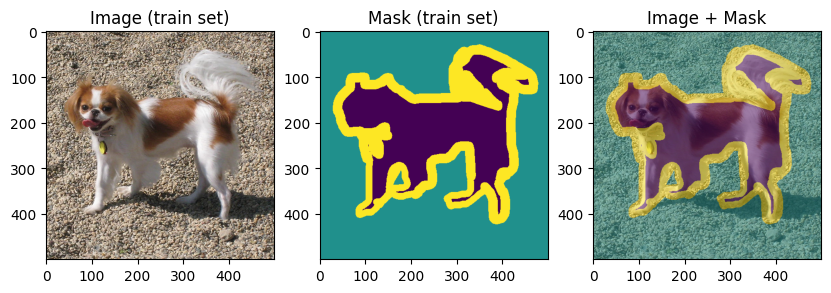

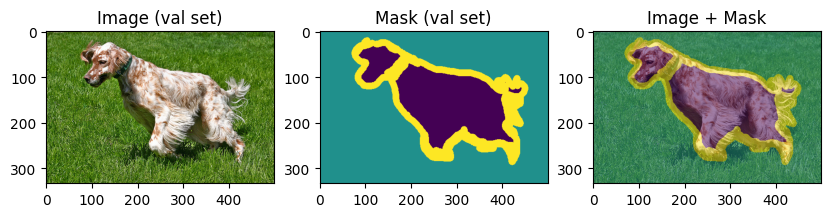

In [6]:
import matplotlib.pyplot as plt


def display_datapoint(datapoint, label=""):
    img, mask = datapoint["image"], datapoint["mask"]
    if img.dtype in (np.float32, ):
        img = ((img - img.min()) / (img.max() - img.min()) * 255.0).astype(np.uint8)
    fig, axs = plt.subplots(1, 3, figsize=(10, 10))
    axs[0].set_title(f"Image{label}")
    axs[0].imshow(img)
    axs[1].set_title(f"Mask{label}")
    axs[1].imshow(mask)
    axs[2].set_title("Image + Mask")
    axs[2].imshow(img)
    axs[2].imshow(mask, alpha=0.5)



display_datapoint(train_dataset[0], label=" (train set)")
display_datapoint(val_dataset[0], label=" (val set)")

### Data augmentations

Next, let's define a simple data augmentation pipeline of joined image and mask transformations using [Albumentations](https://albumentations.ai/docs/examples/example/). We apply geometric and color transformations to increase the diversity of the training data. For more details on the Albumentations transformations, we can check [Albumentations reference API](https://albumentations.ai/docs/api_reference/full_reference/).

In [7]:
import albumentations as albu


img_size = 256

train_transforms = albu.Compose([
    albu.Affine(rotate=(-35, 35), fill_mask=1, p=0.3),  # Random rotations -35 to 35 degrees
    albu.RandomResizedCrop(size=(img_size, img_size), scale=(0.7, 1.0)),  # Crop a random part of the input and rescale it to a specified size
    albu.HorizontalFlip(p=0.5),  # Horizontal random flip
    albu.RandomBrightnessContrast(p=0.4),  # Randomly changes the brightness and contrast
    albu.Normalize(),  # Normalize the image and cast to float
])


val_transforms = albu.Compose([
    albu.Resize(width=img_size, height=img_size),
    albu.Normalize(),  # Normalize the image and cast to float
])

In [8]:
output = train_transforms(**train_dataset[0])
img, mask = output["image"], output["mask"]
print("Image array info:", img.dtype, img.shape, img.min(), img.mean(), img.max())
print("Mask array info:", mask.dtype, mask.shape, mask.min(), mask.max())

Image array info: float32 (256, 256, 3) -2.117904 0.12848356 2.5702832
Mask array info: uint8 (256, 256) 0 2


In [9]:
output = val_transforms(**val_dataset[0])
img, mask = output["image"], output["mask"]
print("Image array info:", img.dtype, img.shape, img.min(), img.mean(), img.max())
print("Mask array info:", mask.dtype, mask.shape, mask.min(), mask.max())

Image array info: float32 (256, 256, 3) -2.117904 -0.30076742 2.6399999
Mask array info: uint8 (256, 256) 0 2


### Data loaders

Let's now use [`grain`](https://github.com/google/grain) to perform data loading, augmentations and batching on a single device using multiple workers. We will create a random index sampler for training and an unshuffled sampler for validation.

In [10]:
from typing import Any, Callable

import grain.python as grain


class DataAugs(grain.MapTransform):
    def __init__(self, transforms: Callable):
        self.albu_transforms = transforms

    def map(self, data):
        output = self.albu_transforms(**data)
        return output

In [11]:
train_batch_size = 72
val_batch_size = 2 * train_batch_size


# Create an IndexSampler with no sharding for single-device computations
train_sampler = grain.IndexSampler(
    len(train_dataset),  # The total number of samples in the data source
    shuffle=True,            # Shuffle the data to randomize the order of samples
    seed=seed,               # Set a seed for reproducibility
    shard_options=grain.NoSharding(),  # No multi-host sharding since this is a single host setup.
    num_epochs=1,            # Iterate over the dataset for one epoch
)

val_sampler = grain.IndexSampler(
    len(val_dataset),  # The total number of samples in the data source
    shuffle=False,         # Do not shuffle the data
    seed=seed,             # Set a seed for reproducibility
    shard_options=grain.NoSharding(),  # No multi-host sharding since this is a single host setup.
    num_epochs=1,          # Iterate over the dataset for one epoch
)

In [12]:
train_loader = grain.DataLoader(
    data_source=train_dataset,
    sampler=train_sampler,                 # Sampler to determine how to access the data
    worker_count=4,                        # Number of child processes launched to parallelize the transformations among
    worker_buffer_size=2,                  # Count of output batches to produce in advance per worker
    operations=[
        DataAugs(train_transforms),
        grain.Batch(train_batch_size, drop_remainder=True),
    ]
)

# Validation dataset loader
val_loader = grain.DataLoader(
    data_source=val_dataset,
    sampler=val_sampler,                   # Sampler to determine how to access the data
    worker_count=4,                        # Number of child processes launched to parallelize the transformations among
    worker_buffer_size=2,
    operations=[
        DataAugs(val_transforms),
        grain.Batch(val_batch_size, drop_remainder=True),  # drop remainder for val loader as we shard on batch dim
    ]
)

# Training dataset loader for evaluation (without dataaugs)
train_eval_loader = grain.DataLoader(
    data_source=train_dataset,
    sampler=train_sampler,                 # Sampler to determine how to access the data
    worker_count=4,                        # Number of child processes launched to parallelize the transformations among
    worker_buffer_size=2,                  # Count of output batches to produce in advance per worker
    operations=[
        DataAugs(val_transforms),
        grain.Batch(val_batch_size, drop_remainder=True),
    ]
)

In [13]:
train_batch = next(iter(train_loader))
val_batch = next(iter(val_loader))

In [14]:
print("Train images batch info:", type(train_batch["image"]), train_batch["image"].shape, train_batch["image"].dtype)
print("Train masks batch info:", type(train_batch["mask"]), train_batch["mask"].shape, train_batch["mask"].dtype)

Train images batch info: <class 'grain._src.python.ipc.shared_memory_array.SharedMemoryArray'> (72, 256, 256, 3) float32
Train masks batch info: <class 'grain._src.python.ipc.shared_memory_array.SharedMemoryArray'> (72, 256, 256) uint8


Finally, let's display the training and validation data:

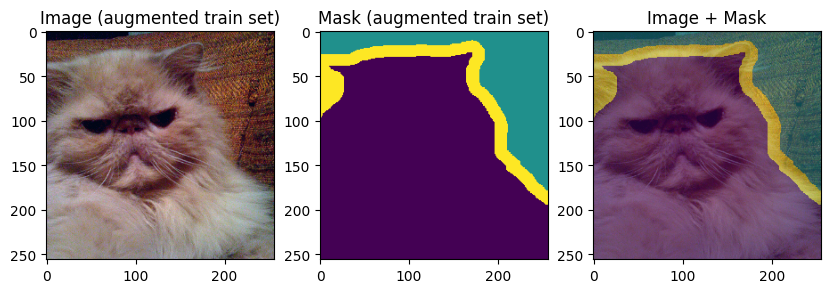

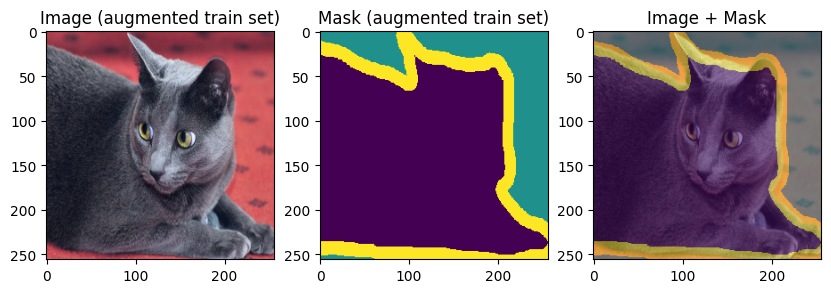

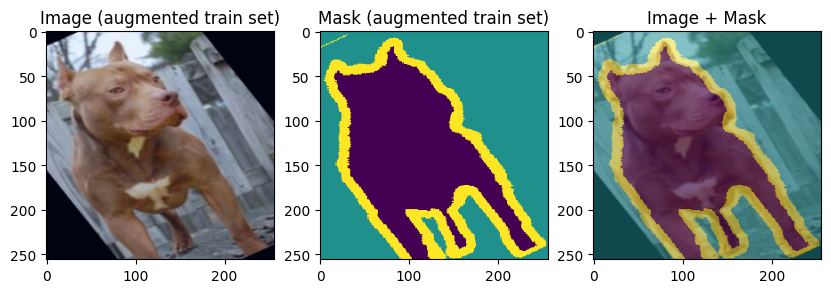

In [15]:
images, masks = train_batch["image"], train_batch["mask"]

for img, mask in zip(images[:3], masks[:3]):
    display_datapoint({"image": img, "mask": mask}, label=" (augmented train set)")

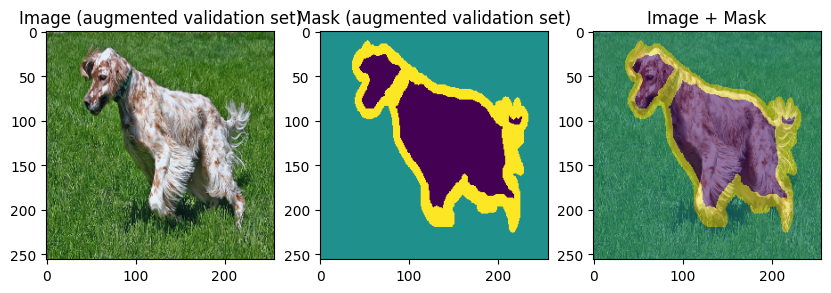

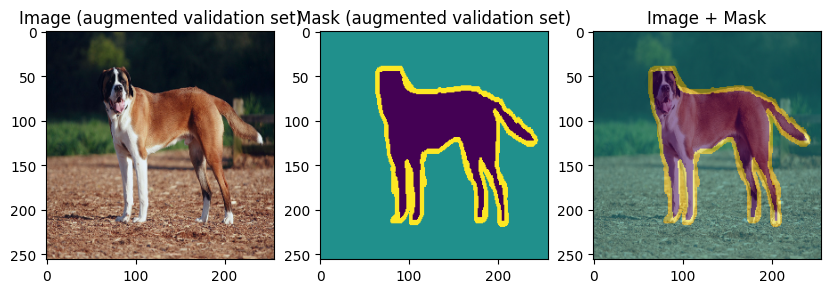

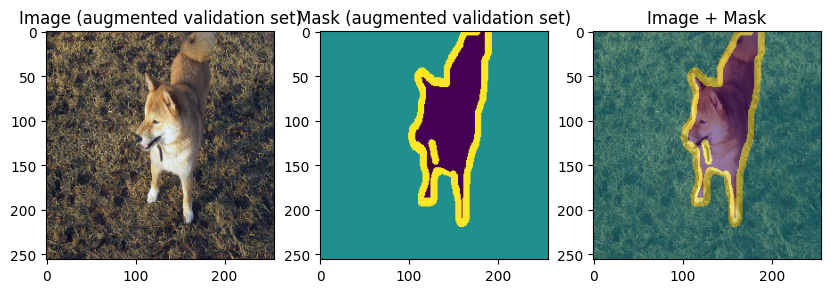

In [16]:
images, masks = val_batch["image"], val_batch["mask"]

for img, mask in zip(images[:3], masks[:3]):
    display_datapoint({"image": img, "mask": mask}, label=" (augmented validation set)")

## Model for Image Segmentation

In this section we will implement the [UNETR](https://arxiv.org/abs/2103.10504) model from scratch using Flax NNX. The reference PyTorch implementation of this model can be found on the [MONAI Library GitHub repository](https://github.com/Project-MONAI/MONAI/blob/dev/monai/networks/nets/unetr.py).

The UNETR model utilizes a transformer as the encoder to learn sequence representations of the input and to capture the global multi-scale information, while also following the “U-shaped” network design like [UNet](https://arxiv.org/abs/1505.04597) model:
![image.png](https://docs.jaxstack.ai/en/latest/_images/unetr_architecture.png)

The UNETR architecture on the image above is processing 3D inputs, but it can be easily adapted to 2D input.

The transformer encoder of UNETR is [Vision Transformer (ViT)](https://arxiv.org/abs/2010.11929). The feature maps returned by ViT have all the same spatial size: (H / 16, W / 16) and deconvolutions are used to upsample the feature maps. Finally, the feature maps are upsampled and concatenated up to the original image size.

In [17]:
from flax import nnx
import jax.numpy as jnp

### Vision Transformer encoder implementation

Below, we will implement the following modules:
- Vision Transformer, `ViT`
  - `PatchEmbeddingBlock`: patch embedding block, which maps patches of pixels to a sequence of vectors
  - `ViTEncoderBlock`: vision transformer encoder block
    - `MLPBlock`: multilayer perceptron block

In [18]:
from dataclasses import dataclass
from jax.sharding import PartitionSpec as P


@dataclass(slots=True, frozen=True)
class ShardingConfig:
    attn_qkvo_weight_ndh: P | None = None  # sharding for Q, K, V, Out weights
    mlp_weight_df: P | None = None
    mlp_weight_fd: P | None = None
    act_btd: P | None = None  # sharding of the activation (B, T, D)
    act_btf: P | None = None
    act_btnh: P | None = None

    fsdp_axis_name: str = "fsdp"

    @staticmethod
    def no_sharding():
        return ShardingConfig()

    @staticmethod
    def fsdp_sharding(fsdp_axis_name: str = "fsdp"):
        fsdp = fsdp_axis_name
        return ShardingConfig(
            attn_qkvo_weight_ndh=P(None, fsdp, None),
            mlp_weight_df=P(fsdp, None),
            mlp_weight_fd=P(None, fsdp),
            act_btd=P(fsdp, None, None),
            act_btf=P(fsdp, None, None),
            act_btnh=P(fsdp, None, None, None),
            fsdp_axis_name=fsdp_axis_name,
        )


@dataclass(slots=True, frozen=True)
class ViTConfig:
    in_channels: int = 3
    img_size: int = 224
    patch_size: int = 16
    num_layers: int = 12
    num_heads: int = 12
    mlp_dim: int = 3072
    hidden_size: int = 768
    dropout_rate: float = 0.1
    sharding: ShardingConfig = ShardingConfig.no_sharding()

In [19]:
from typing import Callable


class PatchEmbedding(nnx.Module):
    def __init__(
        self,
        in_channels: int,  # dimension of input channels.
        img_size: int,  # dimension of input image.
        patch_size: int,  # dimension of patch size.
        hidden_size: int,  # dimension of hidden layer.
        dropout_rate: float = 0.0,
        *,
        rngs: nnx.Rngs = nnx.Rngs(0),
    ):
        n_patches = (img_size // patch_size) ** 2
        self.patch_embeddings = nnx.Conv(
            in_channels,
            hidden_size,
            kernel_size=(patch_size, patch_size),
            strides=(patch_size, patch_size),
            padding="VALID",
            use_bias=True,
            rngs=rngs,
        )

        initializer = jax.nn.initializers.truncated_normal(stddev=0.02)
        self.position_embeddings = nnx.Param(
            initializer(rngs.params(), (1, n_patches, hidden_size), jnp.float32)
        )
        self.dropout = nnx.Dropout(dropout_rate, rngs=rngs)

    def __call__(
        self, 
        x: jax.Array, 
        rngs: nnx.Rngs | None = None, 
        out_sharding: P | None = None,
    ) -> jax.Array:
        x = self.patch_embeddings(x, out_sharding=out_sharding)
        x = x.reshape(x.shape[0], -1, x.shape[-1])
        embeddings = x + self.position_embeddings
        embeddings = self.dropout(embeddings, rngs=rngs)
        return embeddings


class MLPBlock(nnx.Module):
    def __init__(
        self,
        hidden_size: int,  # dimension of hidden layer.
        mlp_dim: int,      # dimension of feedforward layer
        dropout_rate: float = 0.0,
        activation_layer: Callable = nnx.gelu,
        *,
        rngs: nnx.Rngs = nnx.Rngs(0),
        up_proj_sharding: P | None = None,
        down_proj_sharding: P | None = None,
    ):
        self.up_proj = nnx.Linear(
            hidden_size, 
            mlp_dim, 
            rngs=rngs,
            kernel_metadata={"out_sharding": up_proj_sharding},
        )
        self.act = activation_layer
        self.drop = nnx.Dropout(dropout_rate, rngs=rngs)
        self.down_proj = nnx.Linear(
            mlp_dim, 
            hidden_size, 
            rngs=rngs,
            kernel_metadata={"out_sharding": down_proj_sharding},
        )

    def __call__(
        self, 
        x: jax.Array, 
        rngs: nnx.Rngs | None = None,
        up_proj_out_sharding: P | None = None,
        out_sharding: P | None = None,        
    ) -> jax.Array:
        x = self.up_proj(x, out_sharding=up_proj_out_sharding)
        x = self.act(x)
        x = self.drop(x)
        x = self.down_proj(x, out_sharding=out_sharding)
        return self.drop(x)


class ViTEncoderBlock(nnx.Module):
    def __init__(
        self,
        hidden_size: int,  # dimension of hidden layer.
        mlp_dim: int,      # dimension of feedforward layer.
        num_heads: int,    # number of attention heads
        dropout_rate: float = 0.0,
        *,
        rngs: nnx.Rngs = nnx.Rngs(0),
        sharding: ShardingConfig = ShardingConfig(),
    ) -> None:
        self.mlp = MLPBlock(
            hidden_size, 
            mlp_dim, 
            dropout_rate, 
            rngs=rngs, 
            up_proj_sharding=sharding.mlp_weight_df,
            down_proj_sharding=sharding.mlp_weight_fd,
        )
        self.norm1 = nnx.LayerNorm(hidden_size, rngs=rngs)
        self.attn = nnx.MultiHeadAttention(
            num_heads=num_heads,
            in_features=hidden_size,
            dropout_rate=dropout_rate,
            broadcast_dropout=False,
            decode=False,
            deterministic=False,
            rngs=rngs,
            keep_rngs=False,
            kernel_metadata={"out_sharding": sharding.attn_qkvo_weight_ndh},
            out_kernel_metadata={"out_sharding": sharding.attn_qkvo_weight_ndh},            
        )
        self.norm2 = nnx.LayerNorm(hidden_size, rngs=rngs)
        self.sharding = sharding

    def __call__(
        self, 
        x: jax.Array,
        rngs: nnx.Rngs | None = None,
    ) -> jax.Array:
        x = x + self.attn(
            self.norm1(x), 
            rngs=rngs,
            out_sharding=self.sharding.act_btd,
            qkv_sharding=self.sharding.act_btnh,            
        )
        x = x + self.mlp(
            self.norm2(x),
            rngs=rngs,
            out_sharding=self.sharding.act_btd,
            up_proj_out_sharding=self.sharding.act_btf,            
        )
        return x


class ViT(nnx.Module):
    def __init__(
        self,
        config,
        *,
        rngs: nnx.Rngs = nnx.Rngs(0),
    ):
        if config.hidden_size % config.num_heads != 0:
            raise ValueError("hidden_size should be divisible by num_heads.")

        self.config = config
        self.patch_embedding = PatchEmbedding(
            in_channels=config.in_channels,
            img_size=config.img_size,
            patch_size=config.patch_size,
            hidden_size=config.hidden_size,
            dropout_rate=config.dropout_rate,
            rngs=rngs,
        )
        self.blocks = nnx.List([
            ViTEncoderBlock(
                config.hidden_size, 
                config.mlp_dim, 
                config.num_heads, 
                config.dropout_rate, 
                rngs=rngs,
                sharding=config.sharding,
            )
            for i in range(config.num_layers)
        ])
        self.norm = nnx.LayerNorm(config.hidden_size, rngs=rngs)

    def __call__(
        self, 
        x: jax.Array,
        rngs: nnx.Rngs | None = None,
    ) -> jax.Array:
        x = self.patch_embedding(
            x, 
            rngs=rngs,
            out_sharding=self.config.sharding.act_btd,
        )
        hidden_states_out = []
        for blk in self.blocks:
            x = blk(x, rngs=rngs)
            hidden_states_out.append(x)
        x = self.norm(x)
        return x, hidden_states_out


config = ViTConfig()
mod = ViT(config)
x = jnp.ones((4, 224, 224, 3))
y, hstates = mod(x, rngs=nnx.Rngs(1))
print(y.shape, len(hstates))
del mod, x

(4, 196, 768) 12


At this point we implemented the encoder of the UNETR model. As we can see from the above output, ViT provides one encoded feature map and a list of intermediate feature maps. Three of them will be used in the decoding part.

### UNETR blocks implementation

Now, we can implement remaining blocks and assemble them together in the UNETR implementation

Below, we will implement the following modules:
- `UNETR`
  - `UnetrBasicBlock`: creates the first skip connection from the input.
    - `UnetResBlock`
  - `UnetrPrUpBlock`: projection upsampling modules to create skip connections from the intermediate feature maps provided by ViT.
  - `UnetrUpBlock`: upsampling modules used in the decoder

In [20]:
class Conv2dNormActivation(nnx.Sequential):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        stride: int = 1,
        padding: int | None = None,
        groups: int = 1,
        norm_layer: Callable[..., nnx.Module] = nnx.BatchNorm,
        activation_layer: Callable = nnx.relu,
        dilation: int = 1,
        bias: bool | None = None,
        rngs: nnx.Rngs = nnx.Rngs(0),
    ):
        self.out_channels = out_channels

        if padding is None:
            padding = (kernel_size - 1) // 2 * dilation
        if bias is None:
            bias = norm_layer is None

        # sequence integer pairs that give the padding to apply before
        # and after each spatial dimension
        padding = ((padding, padding), (padding, padding))

        layers = [
            nnx.Conv(
                in_channels,
                out_channels,
                kernel_size=(kernel_size, kernel_size),
                strides=(stride, stride),
                padding=padding,
                kernel_dilation=(dilation, dilation),
                feature_group_count=groups,
                use_bias=bias,
                rngs=rngs,
            )
        ]

        if norm_layer is not None:
            layers.append(norm_layer(out_channels, rngs=rngs))

        if activation_layer is not None:
            layers.append(activation_layer)

        super().__init__(*layers)

In [21]:
class InstanceNorm(nnx.GroupNorm):
    def __init__(self, num_features, **kwargs):
        num_groups, group_size = num_features, None
        super().__init__(
            num_features,
            num_groups=num_groups,
            group_size=group_size,
            **kwargs,
        )


class UnetResBlock(nnx.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        stride: int,
        norm_layer: Callable[..., nnx.Module] = InstanceNorm,
        activation_layer: Callable = nnx.leaky_relu,
        *,
        rngs: nnx.Rngs = nnx.Rngs(0),
    ):
        self.conv_norm_act1 = Conv2dNormActivation(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            norm_layer=norm_layer,
            activation_layer=activation_layer,
            rngs=rngs,
        )
        self.conv_norm2 = Conv2dNormActivation(
            in_channels=out_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=1,
            norm_layer=norm_layer,
            activation_layer=None,
            rngs=rngs,
        )

        self.downsample = (in_channels != out_channels) or (stride != 1)
        if self.downsample:
            self.conv_norm3 = Conv2dNormActivation(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=1,
                stride=stride,
                norm_layer=norm_layer,
                activation_layer=None,
                rngs=rngs,
            )
        self.act = activation_layer

    def __call__(self, x: jax.Array) -> jax.Array:
        residual = x
        out = self.conv_norm_act1(x)
        out = self.conv_norm2(out)
        if self.downsample:
            residual = self.conv_norm3(residual)
        out += residual
        out = self.act(out)
        return out

In [22]:
class UnetrBasicBlock(nnx.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        stride: int,
        norm_layer: Callable[..., nnx.Module] = InstanceNorm,
        *,
        rngs: nnx.Rngs = nnx.Rngs(0),
    ):
        self.layer = UnetResBlock(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            norm_layer=norm_layer,
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        return self.layer(x)

In [23]:
class UnetrPrUpBlock(nnx.Module):
    def __init__(
        self,
        in_channels: int,  # number of input channels.
        out_channels: int, # number of output channels.
        num_layer: int,    # number of upsampling blocks.
        kernel_size: int,
        stride: int,
        upsample_kernel_size: int = 2,  # convolution kernel size for transposed convolution layers.
        norm_layer: Callable[..., nnx.Module] = InstanceNorm,
        *,
        rngs: nnx.Rngs = nnx.Rngs(0),
    ):
        upsample_stride = upsample_kernel_size
        self.transp_conv_init = nnx.ConvTranspose(
            in_features=in_channels,
            out_features=out_channels,
            kernel_size=(upsample_kernel_size, upsample_kernel_size),
            strides=(upsample_stride, upsample_stride),
            padding="VALID",
            rngs=rngs,
        )
        self.blocks = nnx.List([
            nnx.Sequential(
                nnx.ConvTranspose(
                    in_features=out_channels,
                    out_features=out_channels,
                    kernel_size=(upsample_kernel_size, upsample_kernel_size),
                    strides=(upsample_stride, upsample_stride),
                    rngs=rngs,
                ),
                UnetResBlock(
                    in_channels=out_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size,
                    stride=stride,
                    norm_layer=norm_layer,
                    rngs=rngs,
                ),
            )
            for i in range(num_layer)
        ])

    def __call__(self, x: jax.Array) -> jax.Array:
        x = self.transp_conv_init(x)
        for blk in self.blocks:
            x = blk(x)
        return x

In [24]:
class UnetrUpBlock(nnx.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        upsample_kernel_size: int = 2,  # convolution kernel size for transposed convolution layers.
        norm_layer: Callable[..., nnx.Module] = InstanceNorm,
        *,
        rngs: nnx.Rngs = nnx.Rngs(0),
    ) -> None:
        upsample_stride = upsample_kernel_size
        self.transp_conv = nnx.ConvTranspose(
            in_features=in_channels,
            out_features=out_channels,
            kernel_size=(upsample_kernel_size, upsample_kernel_size),
            strides=(upsample_stride, upsample_stride),
            padding="VALID",
            rngs=rngs,
        )
        self.conv_block = UnetResBlock(
            out_channels + out_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=1,
            norm_layer=norm_layer,
            rngs=rngs,
        )

    def __call__(self, x: jax.Array, skip: jax.Array) -> jax.Array:
        out = self.transp_conv(x)
        out = jnp.concat((out, skip), axis=-1)
        out = self.conv_block(out)
        return out

In [25]:
@dataclass(slots=True, frozen=True)
class ModelConfig:
    out_channels: int
    vit_config: ViTConfig
    feature_size: int = 16
    norm_layer: Callable[..., nnx.Module] = InstanceNorm


class UNETR(nnx.Module):
    """UNETR model ported to NNX from MONAI implementation:
    - https://github.com/Project-MONAI/MONAI/blob/dev/monai/networks/nets/unetr.py
    """
    def __init__(
        self,
        config: ModelConfig,
        *,
        rngs: nnx.Rngs = nnx.Rngs(0),
    ):
        self.config = config
        vit_config = config.vit_config
        feat_size = vit_config.img_size // vit_config.patch_size

        self.vit = ViT(
            config=config.vit_config,
            rngs=rngs,
        )
        self.encoder1 = UnetrBasicBlock(
            in_channels=vit_config.in_channels,
            out_channels=config.feature_size,
            kernel_size=3,
            stride=1,
            norm_layer=config.norm_layer,
            rngs=rngs,
        )
        self.encoder2 = UnetrPrUpBlock(
            in_channels=vit_config.hidden_size,
            out_channels=config.feature_size * 2,
            num_layer=2,
            kernel_size=3,
            stride=1,
            upsample_kernel_size=2,
            norm_layer=config.norm_layer,
            rngs=rngs,
        )
        self.encoder3 = UnetrPrUpBlock(
            in_channels=vit_config.hidden_size,
            out_channels=config.feature_size * 4,
            num_layer=1,
            kernel_size=3,
            stride=1,
            upsample_kernel_size=2,
            norm_layer=config.norm_layer,
            rngs=rngs,
        )
        self.encoder4 = UnetrPrUpBlock(
            in_channels=vit_config.hidden_size,
            out_channels=config.feature_size * 8,
            num_layer=0,
            kernel_size=3,
            stride=1,
            upsample_kernel_size=2,
            norm_layer=config.norm_layer,
            rngs=rngs,
        )
        self.decoder5 = UnetrUpBlock(
            in_channels=vit_config.hidden_size,
            out_channels=config.feature_size * 8,
            kernel_size=3,
            upsample_kernel_size=2,
            norm_layer=config.norm_layer,
            rngs=rngs,
        )
        self.decoder4 = UnetrUpBlock(
            in_channels=config.feature_size * 8,
            out_channels=config.feature_size * 4,
            kernel_size=3,
            upsample_kernel_size=2,
            norm_layer=config.norm_layer,
            rngs=rngs,
        )
        self.decoder3 = UnetrUpBlock(
            in_channels=config.feature_size * 4,
            out_channels=config.feature_size * 2,
            kernel_size=3,
            upsample_kernel_size=2,
            norm_layer=config.norm_layer,
            rngs=rngs,
        )
        self.decoder2 = UnetrUpBlock(
            in_channels=config.feature_size * 2,
            out_channels=config.feature_size,
            kernel_size=3,
            upsample_kernel_size=2,
            norm_layer=config.norm_layer,
            rngs=rngs,
        )

        self.out = nnx.Conv(
            in_features=config.feature_size,
            out_features=config.out_channels,
            kernel_size=(1, 1),
            strides=(1, 1),
            padding="VALID",
            use_bias=True,
            rngs=rngs,
        )

        self.proj_axes = (0, 1, 2, 3)
        self.proj_view_shape = [feat_size, feat_size, vit_config.hidden_size]

    def proj_feat(self, x: jax.Array) -> jax.Array:
        new_view = [x.shape[0]] + self.proj_view_shape
        x = x.reshape(new_view)
        x = jnp.permute_dims(x, self.proj_axes)
        return x

    def __call__(
        self, 
        x_in: jax.Array,
        rngs: nnx.Rngs | None = None,
    ) -> jax.Array:
        x, hidden_states_out = self.vit(x_in, rngs=rngs)
        enc1 = self.encoder1(x_in)
        x2 = hidden_states_out[3]
        enc2 = self.encoder2(self.proj_feat(x2))
        x3 = hidden_states_out[6]
        enc3 = self.encoder3(self.proj_feat(x3))
        x4 = hidden_states_out[9]
        enc4 = self.encoder4(self.proj_feat(x4))
        dec4 = self.proj_feat(x)
        dec3 = self.decoder5(dec4, enc4)
        dec2 = self.decoder4(dec3, enc3)
        dec1 = self.decoder3(dec2, enc2)
        out = self.decoder2(dec1, enc1)
        return self.out(out)

In [26]:
# We'll use a different number of heads to make a smaller model
mesh = jax.make_mesh((jax.device_count(),), ("fsdp",))
with jax.set_mesh(mesh):
    config = ModelConfig(
        out_channels=3, 
        vit_config=ViTConfig(
            num_heads=4,
            img_size=256,
            sharding=ShardingConfig.fsdp_sharding()
        ),
    )
    model = UNETR(config, rngs=nnx.Rngs(0))
    x = jnp.ones((4, 256, 256, 3), out_sharding=jax.P("fsdp"))
    y = model(x, rngs=nnx.Rngs(0))
    print("Predictions shape: ", jax.typeof(y))

E0519 14:57:51.784197   56855 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 14:57:53.856762   56823 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 14:58:00.225197   56823 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 14:58:01.807232   56813 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 14:58:03.571723   56835 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Predictions shape:  float32[4@fsdp,256,256,3]


We can visualize and inspect the architecture on the implemented model using `nnx.display(model)`.

## Train the model

In previous sections we defined training and validation dataloaders and the model. In this section we will train the model and define the loss function and the optimizer to perform the parameters optimization.

For the semantic segmentation task, we can define the loss function as a sum of Cross-Entropy and Jaccard loss functions. The Cross-Entropy loss function is a standard loss function for a multi-class classification tasks and the Jaccard loss function helps directly optimizing Intersection-over-Union measure for semantic segmentation.

In [27]:
import optax

num_epochs = 15
total_steps = len(train_dataset) // train_batch_size
learning_rate = 0.003
momentum = 0.9

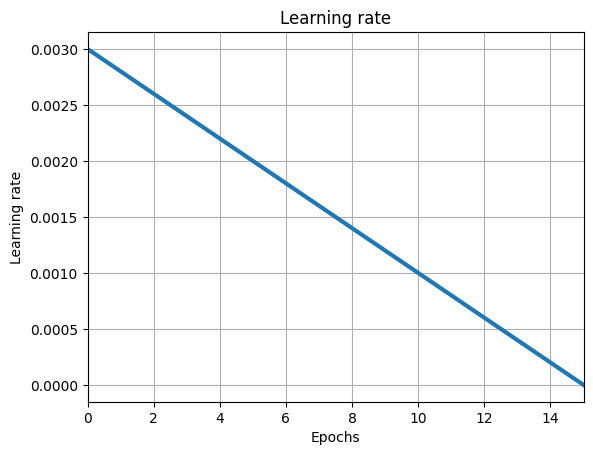

In [28]:
lr_schedule = optax.linear_schedule(learning_rate, 0.0, num_epochs * total_steps)

iterate_subsample = np.linspace(0, num_epochs * total_steps, 100)
plt.plot(
    np.linspace(0, num_epochs, len(iterate_subsample)),
    [lr_schedule(i) for i in iterate_subsample],
    lw=3,
)
plt.title("Learning rate")
plt.xlabel("Epochs")
plt.ylabel("Learning rate")
plt.grid()
plt.xlim((0, num_epochs))
plt.show()

with jax.set_mesh(mesh):
    optimizer = nnx.Optimizer(model, optax.adam(lr_schedule, momentum), wrt=nnx.Param)

Let us implement Jaccard loss and the loss function combining Cross-Entropy and Jaccard losses.

In [29]:
def compute_softmax_jaccard_loss(logits, masks, reduction="mean"):
    assert reduction in ("mean", "sum")
    y_pred = nnx.softmax(logits, axis=-1)
    b, c = y_pred.shape[0], y_pred.shape[-1]
    y = nnx.one_hot(masks, num_classes=c, axis=-1)

    y_pred = y_pred.reshape((b, -1, c))
    y = y.reshape((b, -1, c))

    intersection = y_pred * y
    union = y_pred + y - intersection + 1e-8

    intersection = jnp.sum(intersection, axis=1)
    union = jnp.sum(union, axis=1)

    if reduction == "mean":
        intersection = jnp.mean(intersection)
        union = jnp.mean(union)
    elif reduction == "sum":
        intersection = jnp.sum(intersection)
        union = jnp.sum(union)

    return 1.0 - intersection / union


def compute_losses_and_logits(
    model: nnx.Module, 
    images: jax.Array, 
    masks: jax.Array,
    rngs: nnx.Rngs | None = None,
):
    logits = model(images, rngs=rngs)
    xentropy_loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=masks
    ).mean()
    jacc_loss = compute_softmax_jaccard_loss(logits=logits, masks=masks)
    loss = xentropy_loss + jacc_loss
    return loss, (xentropy_loss, jacc_loss, logits)

Now, we will implement a confusion matrix metric derived from [`nnx.Metric`](https://flax.readthedocs.io/en/latest/api_reference/flax.nnx/training/metrics.html#flax.nnx.metrics.Metric). A confusion matrix will help us to compute the Intersection-Over-Union (IoU) metric per class and on average. Finally, we can also compute the accuracy metric using the confusion matrix.

In [30]:
class ConfusionMatrix(nnx.Metric):
    def __init__(
        self,
        num_classes: int,
        average: str | None = None,
    ):
        assert average in (None, "samples", "recall", "precision")
        assert num_classes > 0
        self.num_classes = num_classes
        self.average = average
        self.confusion_matrix = nnx.metrics.MetricState(
            jnp.zeros((self.num_classes, self.num_classes), dtype=jnp.int32)
        )
        self.count = nnx.metrics.MetricState(jnp.array(0, dtype=jnp.int32))

    def reset(self):
        self.confusion_matrix.value = jnp.zeros((self.num_classes, self.num_classes), dtype=jnp.int32)
        self.count.value = jnp.array(0, dtype=jnp.int32)

    def _check_shape(self, y_pred: jax.Array, y: jax.Array):
        if y_pred.shape[-1] != self.num_classes:
            raise ValueError(f"y_pred does not have correct number of classes: {y_pred.shape[-1]} vs {self.num_classes}")

        if not (y.ndim + 1 == y_pred.ndim):
            raise ValueError(
                f"y_pred must have shape (batch_size, num_classes (currently set to {self.num_classes}), ...) "
                "and y must have shape of (batch_size, ...), "
                f"but given {y.shape} vs {y_pred.shape}."
            )

    def update(self, **kwargs):
        # We assume that y.max() < self.num_classes and y.min() >= 0
        assert "y" in kwargs
        assert "y_pred" in kwargs
        y_pred = kwargs["y_pred"]
        y = kwargs["y"]
        self._check_shape(y_pred, y)
        self.count[...] += y_pred.shape[0]

        y_pred = jnp.argmax(y_pred, axis=-1).ravel()
        y = y.ravel()
        indices = self.num_classes * y + y_pred
        if not jax.typeof(indices).sharding.is_fully_replicated:
            indices = jax.sharding.reshard(indices, jax.P())
        matrix = jnp.bincount(indices, minlength=self.num_classes**2, length=self.num_classes**2)
        matrix = matrix.reshape((self.num_classes, self.num_classes))
        self.confusion_matrix[...] += matrix

    def compute(self) -> jax.Array:
        if self.average:
            confusion_matrix = self.confusion_matrix.get_value().astype("float")
            if self.average == "samples":
                return confusion_matrix / self.count.get_value()
            else:
                return self.normalize(self.confusion_matrix.get_value(), self.average)
        return self.confusion_matrix.get_value()

    @staticmethod
    def normalize(matrix: jax.Array, average: str) -> jax.Array:
        """Normalize given `matrix` with given `average`."""
        if average == "recall":
            return matrix / (jnp.expand_dims(matrix.sum(axis=1), axis=1) + 1e-15)
        elif average == "precision":
            return matrix / (matrix.sum(axis=0) + 1e-15)
        else:
            raise ValueError("Argument average should be one of 'samples', 'recall', 'precision'")


def compute_iou(cm: jax.Array) -> jax.Array:
    return jnp.diag(cm) / (cm.sum(axis=1) + cm.sum(axis=0) - jnp.diag(cm) + 1e-15)


def compute_mean_iou(cm: jax.Array) -> jax.Array:
    return compute_iou(cm).mean()


def compute_accuracy(cm: jax.Array) -> jax.Array:
    return jnp.diag(cm).sum() / (cm.sum() + 1e-15)

Next, let's define training and evaluation steps:

In [31]:
@nnx.jit(donate_argnames=("model", "optimizer"))
def train_step(
    model: nnx.Module, 
    optimizer: nnx.Optimizer, 
    rngs: nnx.Rngs,
    batch: tuple[jax.Array, jax.Array],
):
    images, masks = batch
    grad_fn = nnx.value_and_grad(compute_losses_and_logits, has_aux=True)
    (loss, (xentropy_loss, jacc_loss, logits)), grads = grad_fn(model, images, masks, rngs.fork())
    optimizer.update(model, grads)  # In-place updates.

    return loss, xentropy_loss, jacc_loss

In [32]:
@nnx.jit
def eval_step(
    model: nnx.Module, batch: tuple[jax.Array, jax.Array], eval_metrics: nnx.MultiMetric
):
    images, masks = batch
    loss, (_, _, logits) = compute_losses_and_logits(model, images, masks)
    eval_metrics.update(
        total_loss=loss,
        y_pred=logits,
        y=masks,
    )

We will also define metrics we want to compute during the evaluation phase: total loss and confusion matrix computed on training and validation datasets. Finally, we define helper objects to store the metrics history.
Metrics like IoU per class, mean IoU and accuracy will be computed using the confusion matrix in the evaluation code.

In [33]:
eval_metrics = nnx.MultiMetric(
    total_loss=nnx.metrics.Average('total_loss'),
    confusion_matrix=ConfusionMatrix(num_classes=3),
)


eval_metrics_history = {
    "train_total_loss": [],
    "train_IoU": [],
    "train_mean_IoU": [],
    "train_accuracy": [],

    "val_total_loss": [],
    "val_IoU": [],
    "val_mean_IoU": [],
    "val_accuracy": [],
}

Let us define the training and evaluation logic. We define as well a checkpoint manager to store two best models defined by validation mean IoU metric value.

In [34]:
import time
import orbax.checkpoint as ocp
from orbax.checkpoint.checkpoint_managers import preservation_policy as preservation_policy_lib
from orbax.checkpoint.path import atomicity

# We define a view of the model sharing the weights but with attributes set for evaluation
eval_model = nnx.view(model, deterministic=True)
rngs = nnx.Rngs(12)


def train_one_epoch(epoch):
    start_time = time.time()

    with jax.set_mesh(mesh):
        for step, batch in enumerate(train_loader):
    
            # Convert np.ndarray to jax.Array on GPUs
            images = jax.device_put(batch["image"], device=jax.P("fsdp"))
            masks = jax.device_put(batch["mask"].astype(int), device=jax.P("fsdp"))
            
            total_loss, xentropy_loss, jaccard_loss = train_step(model, optimizer, rngs, (images, masks))
    
            print(
                f"\r[train] epoch: {epoch + 1}/{num_epochs}, iteration: {step}/{total_steps}, "
                f"total loss: {total_loss.item():.4f} ",
                f"xentropy loss: {xentropy_loss.item():.4f} ",
                f"jaccard loss: {jaccard_loss.item():.4f} ",
                end="")
            print("\r", end="")

    elapsed = time.time() - start_time
    print(
        f"\n[train] epoch: {epoch + 1}/{num_epochs}, elapsed time: {elapsed:.2f} seconds"
    )


def evaluate_model(epoch):
    start_time = time.time()

    with jax.set_mesh(mesh):
        # Compute the metrics on the train and val sets after each training epoch.
        for tag, eval_loader in [("train", train_eval_loader), ("val", val_loader)]:
            eval_metrics.reset()  # Reset the eval metrics
            for val_batch in eval_loader:
    
                # Convert np.ndarray to jax.Array on GPUs
                images = jax.device_put(val_batch["image"], device=jax.P("fsdp"))
                masks = jax.device_put(val_batch["mask"].astype(int), device=jax.P("fsdp"))
                    
                eval_step(eval_model, (images, masks), eval_metrics)
    
            for metric, value in eval_metrics.compute().items():
                if metric == "confusion_matrix":
                    eval_metrics_history[f"{tag}_IoU"].append(
                        compute_iou(value)
                    )
                    eval_metrics_history[f"{tag}_mean_IoU"].append(
                        compute_mean_iou(value)
                    )
                    eval_metrics_history[f"{tag}_accuracy"].append(
                        compute_accuracy(value)
                    )
                else:
                    eval_metrics_history[f'{tag}_{metric}'].append(value)
    
            print(
                f"[{tag}] epoch: {epoch + 1}/{num_epochs} "
                f"\n - total loss: {eval_metrics_history[f'{tag}_total_loss'][-1]:0.4f} "
                f"\n - IoU per class: {eval_metrics_history[f'{tag}_IoU'][-1].tolist()} "
                f"\n - Mean IoU: {eval_metrics_history[f'{tag}_mean_IoU'][-1]:0.4f} "
                f"\n - Accuracy: {eval_metrics_history[f'{tag}_accuracy'][-1]:0.4f} "
                "\n"
            )

    elapsed = time.time() - start_time
    print(
        f"[evaluation] epoch: {epoch + 1}/{num_epochs}, elapsed time: {elapsed:.2f} seconds"
    )

    return eval_metrics_history['val_mean_IoU'][-1]


checkpoint_path = ocp.test_utils.erase_and_create_empty("/tmp/output-oxford-model/")
checkpoint_mngr = ocp.CheckpointManager(
  checkpoint_path,
  options=ocp.CheckpointManagerOptions(
      preservation_policy=preservation_policy_lib.LatestN(1),
      temporary_path_class=atomicity.CommitFileTemporaryPath,
  ),
)

def save_model(epoch):
    checkpoint_mngr.save(epoch, args=ocp.args.StandardSave(nnx.state(model)))
    checkpoint_mngr.wait_until_finished()

Now we can start the training. It can take around 45 minutes using a single GPU and use 19GB of GPU memory.

In [35]:
%%time

best_val_mean_iou = 0.0
for epoch in range(num_epochs):
    train_one_epoch(epoch)
    if (epoch % 3 == 0) or (epoch == num_epochs - 1):
        val_mean_iou = evaluate_model(epoch)
        if val_mean_iou > best_val_mean_iou:
            save_model(epoch)
            best_val_mean_iou = val_mean_iou

E0519 14:58:32.077355   56846 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 14:58:33.187096   56826 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 14:58:35.464285   56851 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 14:58:35.925939   56849 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 14:58:36.720911   56812 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 14:58:38.163433   56820 cuda_timer.cc:8

[train] epoch: 1/15, iteration: 67/71, total loss: 1.5253  xentropy loss: 0.8606  jaccard loss: 0.6647 
[train] epoch: 1/15, elapsed time: 166.39 seconds


E0519 15:01:03.430295   56840 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 15:01:04.671282   56808 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 15:01:05.447053   56825 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 15:01:05.753242   56839 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 15:01:06.452114   56821 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 15:01:06.968773   56830 cuda_timer.cc:8

[train] epoch: 1/15 
 - total loss: 1.4837 
 - IoU per class: [0.34460192918777466, 0.5718100666999817, 0.09155400097370148] 
 - Mean IoU: 0.3360 
 - Accuracy: 0.6143 

[val] epoch: 1/15 
 - total loss: 1.4854 
 - IoU per class: [0.3414991796016693, 0.570045530796051, 0.09269510954618454] 
 - Mean IoU: 0.3347 
 - Accuracy: 0.6125 

[evaluation] epoch: 1/15, elapsed time: 46.60 seconds
[train] epoch: 2/15, iteration: 67/71, total loss: 1.4079  xentropy loss: 0.7911  jaccard loss: 0.6168 
[train] epoch: 2/15, elapsed time: 63.04 seconds
[train] epoch: 3/15, iteration: 67/71, total loss: 1.3208  xentropy loss: 0.7426  jaccard loss: 0.5781 
[train] epoch: 3/15, elapsed time: 63.87 seconds
[train] epoch: 4/15, iteration: 67/71, total loss: 1.2886  xentropy loss: 0.7257  jaccard loss: 0.5630 
[train] epoch: 4/15, elapsed time: 63.48 seconds
[train] epoch: 4/15 
 - total loss: 1.2749 
 - IoU per class: [0.46864765882492065, 0.6711030602455139, 0.11210985481739044] 
 - Mean IoU: 0.4173 
 - Acc

We can check the saved models:

In [36]:
!ls /tmp/output-oxford-model/

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


14


and visualize collected metrics:

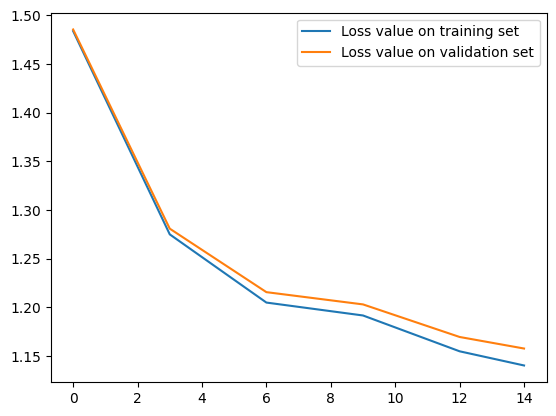

In [37]:
epochs = [i for i in range(num_epochs) if (i % 3 == 0) or (i == num_epochs - 1)]

plt.plot(epochs, eval_metrics_history["train_total_loss"], label="Loss value on training set")
plt.plot(epochs, eval_metrics_history["val_total_loss"], label="Loss value on validation set")
plt.legend()

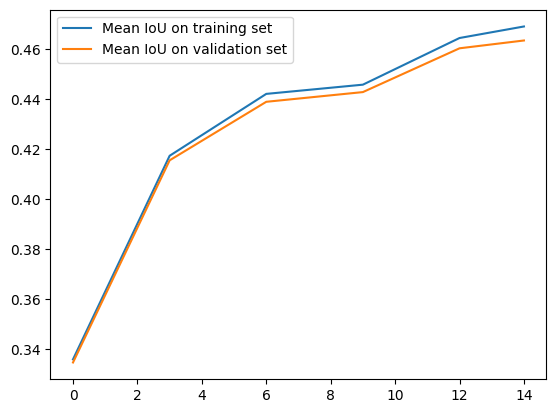

In [38]:
plt.plot(epochs, eval_metrics_history["train_mean_IoU"], label="Mean IoU on training set")
plt.plot(epochs, eval_metrics_history["val_mean_IoU"], label="Mean IoU on validation set")
plt.legend()

Next, we will visualize model predictions on validation data:

In [39]:
val_batch = next(iter(val_loader))

In [40]:
images, masks = val_batch["image"], val_batch["mask"]
with jax.set_mesh(mesh):
    x = jax.device_put(images, device=jax.P("fsdp"))
    preds = eval_model(x)
    preds = jnp.argmax(preds, axis=-1)
    preds = jax.sharding.reshard(preds, jax.P())

E0519 15:19:41.770595   56852 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0519 15:19:49.648804   56825 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


In [41]:
def display_image_mask_pred(img, mask, pred, label=""):
    if img.dtype in (np.float32, ):
        img = ((img - img.min()) / (img.max() - img.min()) * 255.0).astype(np.uint8)
    fig, axs = plt.subplots(1, 5, figsize=(15, 10))
    axs[0].set_title(f"Image{label}")
    axs[0].imshow(img)
    axs[1].set_title(f"Mask{label}")
    axs[1].imshow(mask)
    axs[2].set_title("Image + Mask")
    axs[2].imshow(img)
    axs[2].imshow(mask, alpha=0.5)
    axs[3].set_title(f"Pred{label}")
    axs[3].imshow(pred)
    axs[4].set_title("Image + Pred")
    axs[4].imshow(img)
    axs[4].imshow(pred, alpha=0.5)

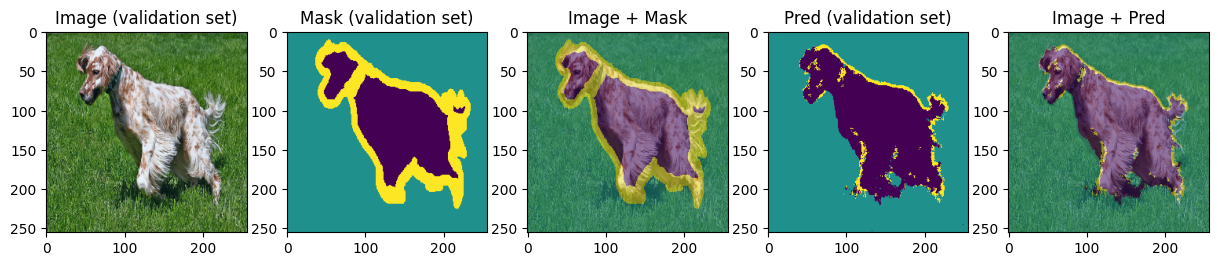

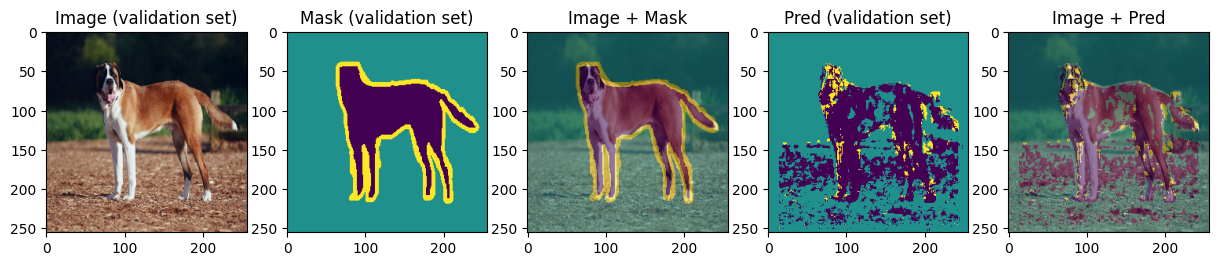

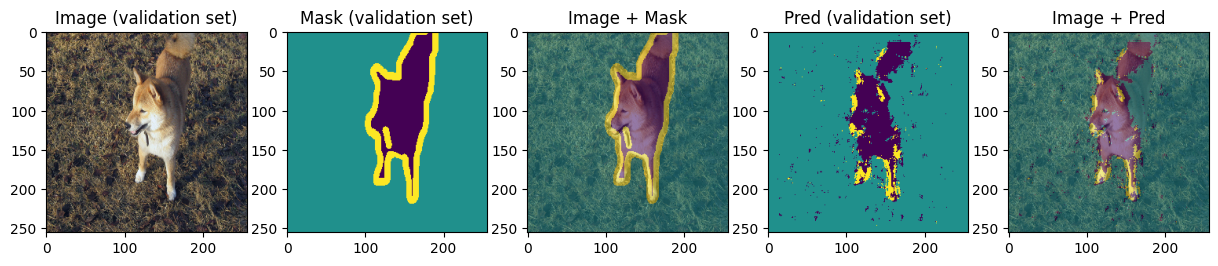

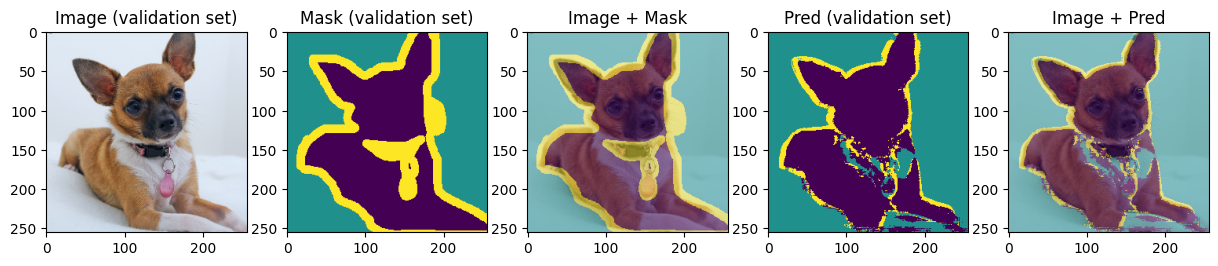

In [42]:
for img, mask, pred in zip(images[:4], masks[:4], preds[:4]):
    display_image_mask_pred(img, mask, pred, label=" (validation set)")

We can see that model can predict approximative shape of the animal and the background and struggles with predicting the boundary. Carefully choosing hyperparameters and training for more epochs we may achieve better results.